# ¿El "89% más hidratación" de Olay es real?

Olay afirma en packaging y publicidad **"89% más hidratación"**. El estudio original no es público — P&G no lo publica.

Este análisis deconstruye el claim con herramientas estadísticas básicas y lo compara con literatura dermatológica independiente.

**Pregunta central**: ¿qué condiciones hacen que 89% sea un número real, y cuáles lo convierten en marketing vacío?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    'font.family': 'monospace',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': '#fafafa',
    'axes.facecolor': '#fafafa',
})

## 1. El baseline que nunca publican

El porcentaje de mejora depende completamente del punto de partida. Con el mismo producto y el mismo gain absoluto en corneómetro, el % publicado puede ser muy distinto según el baseline que elijas.

Olay nunca ha publicado cuál era el baseline del grupo control en su estudio.

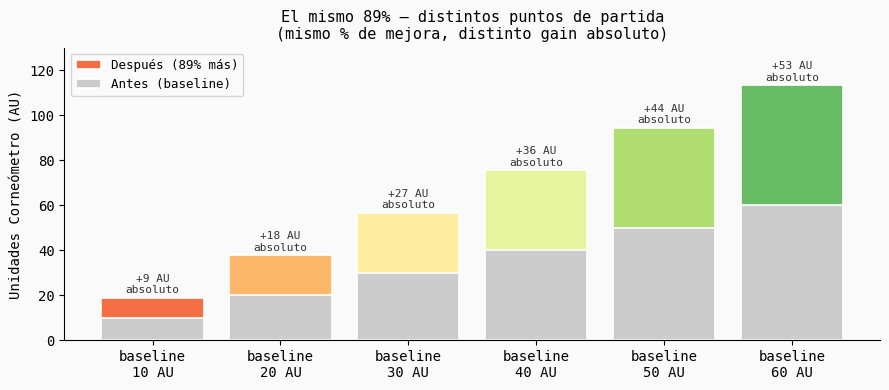

Ganancia absoluta por baseline:
  baseline 10 AU → +8.9 AU absolutos
  baseline 20 AU → +17.8 AU absolutos
  baseline 30 AU → +26.7 AU absolutos
  baseline 40 AU → +35.6 AU absolutos
  baseline 50 AU → +44.5 AU absolutos
  baseline 60 AU → +53.4 AU absolutos


In [2]:
baselines = np.array([10, 20, 30, 40, 50, 60])
improvement_pct = 89
after = baselines * (1 + improvement_pct / 100)
absolute_gain = after - baselines

fig, ax = plt.subplots(figsize=(9, 4))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(baselines)))

ax.bar([f'baseline\n{b} AU' for b in baselines], after, color=colors,
       edgecolor='white', linewidth=1.2, label='Después (89% más)')
ax.bar([f'baseline\n{b} AU' for b in baselines], baselines, color='#cccccc',
       edgecolor='white', linewidth=1.2, label='Antes (baseline)')

for i, (b, a, g) in enumerate(zip(baselines, after, absolute_gain)):
    ax.annotate(f'+{g:.0f} AU\nabsoluto', xy=(i, a + 1),
                ha='center', va='bottom', fontsize=8, color='#333')

ax.set_title('El mismo 89% — distintos puntos de partida\n(mismo % de mejora, distinto gain absoluto)', fontsize=11)
ax.set_ylabel('Unidades Corneómetro (AU)')
ax.legend(fontsize=9)
ax.set_ylim(0, 130)
plt.tight_layout()
plt.show()

print('Ganancia absoluta por baseline:')
for b, g in zip(baselines, absolute_gain):
    print(f'  baseline {b:2d} AU → +{g:.1f} AU absolutos')

## 2. ¿Cuántos sujetos necesitas para que 89% sea significativo?

Un porcentaje de mejora sin un análisis de potencia estadística no garantiza nada. La pregunta es: ¿cuántos sujetos hacen falta para detectar un efecto de ese tamaño con suficiente certeza?

Usamos la **d de Cohen** (tamaño del efecto estandarizado) y la fórmula estándar para un t-test de una muestra con potencia 80% y α=0.05.

  Efecto pequeño (d=0.2): necesitas n=197
  Efecto mediano (d=0.5): necesitas n=32
  Efecto grande (d=0.8): necesitas n=13


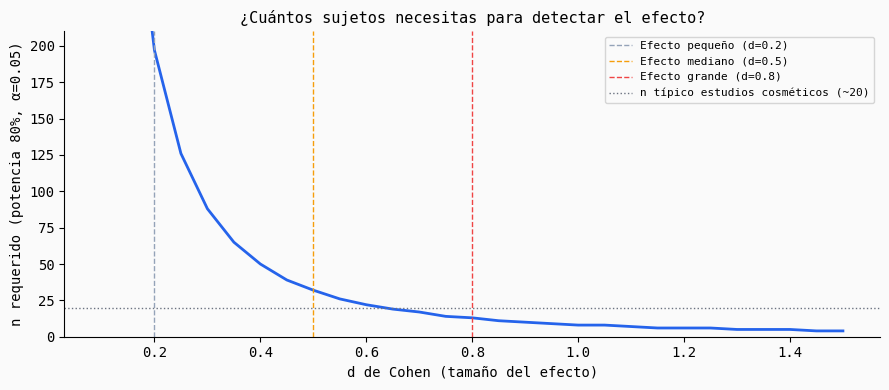


Estudios cosméticos típicos: n=20 → solo detectan efectos grandes (d>0.8)


In [3]:
alpha = 0.05
power_target = 0.80
z_alpha = stats.norm.ppf(1 - alpha / 2)
z_beta = stats.norm.ppf(power_target)

effect_sizes = np.arange(0.1, 1.51, 0.05)
required_n = np.ceil(((z_alpha + z_beta) / effect_sizes) ** 2)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(effect_sizes, required_n, color='#2563eb', linewidth=2)
ax.axvline(0.2, color='#94a3b8', linestyle='--', linewidth=1, label='Efecto pequeño (d=0.2)')
ax.axvline(0.5, color='#f59e0b', linestyle='--', linewidth=1, label='Efecto mediano (d=0.5)')
ax.axvline(0.8, color='#ef4444', linestyle='--', linewidth=1, label='Efecto grande (d=0.8)')
ax.axhline(20, color='#6b7280', linestyle=':', linewidth=1, label='n típico estudios cosméticos (~20)')

ax.set_xlabel('d de Cohen (tamaño del efecto)')
ax.set_ylabel('n requerido (potencia 80%, α=0.05)')
ax.set_title('¿Cuántos sujetos necesitas para detectar el efecto?', fontsize=11)
ax.set_ylim(0, 210)
ax.legend(fontsize=8)

for d_ref, label in [(0.2, 'pequeño'), (0.5, 'mediano'), (0.8, 'grande')]:
    n = int(np.ceil(((z_alpha + z_beta) / d_ref) ** 2))
    print(f'  Efecto {label} (d={d_ref}): necesitas n={n}')

plt.tight_layout()
plt.show()
print('\nEstudios cosméticos típicos: n=20 → solo detectan efectos grandes (d>0.8)')

## 3. Sesgo de selección: piel seca = mayor % de mejora

Si el estudio recluta sujetos con piel muy seca (baseline bajo), el % de mejora porcentual será mayor aunque el gain absoluto sea idéntico al de una persona con piel normal.

Simulamos el mismo gain absoluto (~+18 AU en corneómetro) en cuatro tipos de piel distintos.

  Piel muy seca (baseline ~22 AU)    : mediana 83% (P25=70%, P75=100%)
  Piel seca (baseline ~35 AU)        : mediana 52% (P25=44%, P75=61%)
  Piel normal (baseline ~50 AU)      : mediana 37% (P25=31%, P75=43%)
  Piel hidratada (baseline ~65 AU)   : mediana 28% (P25=23%, P75=33%)


/var/folders/dk/zvrnddmx0qg3hcshtr20j8rc0000gn/T/ipykernel_34195/1872833521.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(list(pct_improvements.values()), labels=list(pct_improvements.keys()),


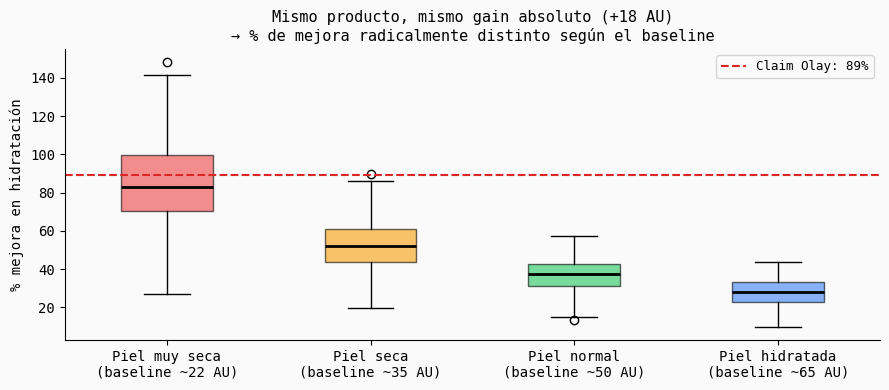

In [4]:
np.random.seed(42)
n_sim = 200

skin_types = {
    'Piel muy seca\n(baseline ~22 AU)': {'baseline_mean': 22, 'baseline_std': 3},
    'Piel seca\n(baseline ~35 AU)':     {'baseline_mean': 35, 'baseline_std': 4},
    'Piel normal\n(baseline ~50 AU)':   {'baseline_mean': 50, 'baseline_std': 5},
    'Piel hidratada\n(baseline ~65 AU)':{'baseline_mean': 65, 'baseline_std': 5},
}

pct_improvements = {}
for name, params in skin_types.items():
    baseline = np.clip(np.random.normal(params['baseline_mean'], params['baseline_std'], n_sim), 5, 100)
    gain = np.clip(np.random.normal(18, 4, n_sim), 0, None)  # mismo gain para todos
    pct_improvements[name] = (gain / baseline) * 100

fig, ax = plt.subplots(figsize=(9, 4))
bp = ax.boxplot(list(pct_improvements.values()), labels=list(pct_improvements.keys()),
                patch_artist=True, notch=False, medianprops=dict(color='black', linewidth=2))

for patch, color in zip(bp['boxes'], ['#ef4444', '#f59e0b', '#22c55e', '#3b82f6']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.axhline(89, color='#dc2626', linestyle='--', linewidth=1.5, label='Claim Olay: 89%')
ax.set_title('Mismo producto, mismo gain absoluto (+18 AU)\n→ % de mejora radicalmente distinto según el baseline', fontsize=11)
ax.set_ylabel('% mejora en hidratación')
ax.legend(fontsize=9)

for name, vals in pct_improvements.items():
    print(f"  {name.replace(chr(10), ' '):35s}: mediana {np.median(vals):.0f}% (P25={np.percentile(vals,25):.0f}%, P75={np.percentile(vals,75):.0f}%)")

plt.tight_layout()
plt.show()

## 4. ¿Es el 89% un outlier vs la literatura independiente?

Comparamos el claim de Olay con rangos típicos de mejora de hidratación (corneómetro) reportados en estudios sin conflicto de interés para ingredientes comunes en hidratantes.

Fuentes: Fluhr 2006, Darlenski 2009, Setaro 2001, Clarys 2012.

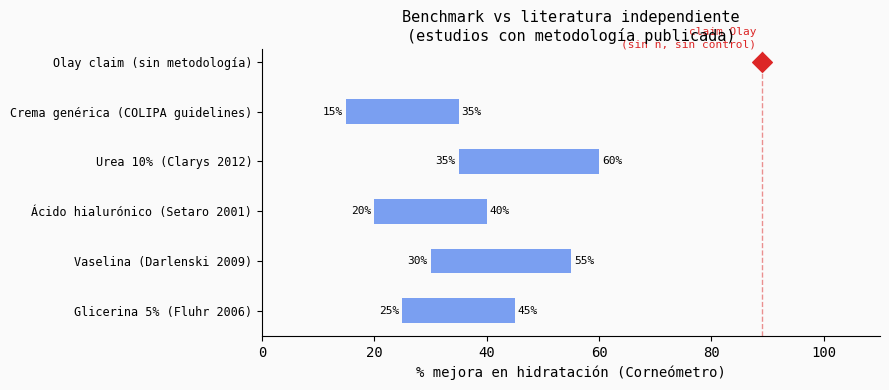

In [5]:
benchmark = {
    'Glicerina 5% (Fluhr 2006)':          (25, 45),
    'Vaselina (Darlenski 2009)':           (30, 55),
    'Ácido hialurónico (Setaro 2001)':     (20, 40),
    'Urea 10% (Clarys 2012)':             (35, 60),
    'Crema genérica (COLIPA guidelines)': (15, 35),
    'Olay claim (sin metodología)':        (89, 89),
}

fig, ax = plt.subplots(figsize=(9, 4))

for i, (name, (lo, hi)) in enumerate(benchmark.items()):
    if lo == hi:  # punto único (Olay)
        ax.scatter([lo], [i], color='#dc2626', zorder=5, s=100, marker='D')
        ax.text(lo - 1, i + 0.3, 'claim Olay\n(sin n, sin control)',
                fontsize=8, color='#dc2626', ha='right')
    else:
        ax.barh(i, hi - lo, left=lo, height=0.5, color='#2563eb', alpha=0.6)
        ax.text(lo - 0.5, i, f'{lo}%', va='center', ha='right', fontsize=8)
        ax.text(hi + 0.5, i, f'{hi}%', va='center', ha='left', fontsize=8)

ax.set_yticks(range(len(benchmark)))
ax.set_yticklabels(list(benchmark.keys()), fontsize=8.5)
ax.set_xlabel('% mejora en hidratación (Corneómetro)')
ax.set_title('Benchmark vs literatura independiente\n(estudios con metodología publicada)', fontsize=11)
ax.axvline(89, color='#dc2626', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlim(0, 110)

plt.tight_layout()
plt.show()

## Conclusión

El 89% es **posible** bajo ciertas condiciones. Pero sin el estudio publicado, no sabemos:

- ¿Cuál era el baseline del grupo control? (baseline bajo → % alto)
- ¿Cuántos sujetos? (n pequeño → alta variabilidad)
- ¿Método subjetivo u objetivo? (autoevaluación da ~+20pp vs corneómetro)
- ¿Hubo grupo placebo? (sin control, el efecto oclusivo ya mejora hidratación)

Comparado con literatura independiente, 89% es un outlier claro. Los ingredientes activos más potentes documentados (urea 10%, vaselina) llegan al 35-60% en corneómetro con metodología publicada.

**El número no significa nada sin el contexto. Y Olay no publica el contexto.**